<a href="https://colab.research.google.com/github/brunafflopez/redeneural/blob/main/Rede_Neural_Cancer_de_Mama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Rede Neural para Diagnóstico de Câncer de Mama**

**Integrantes do Grupo**

* Bruna Fanti Ferreira Lopez
* Ryan Gabriel De Souza Lopes Fidelis

**Introdução**

A base de dados escolhida foi de Conjunto de dados de diagnóstico de câncer de mama em Wisconsin para classificar cancer de mama em benigno e malígno de acordo com algumas caracteristicas.
utilzamos as variáveis de textura e tamanho do câncer para classificar se é benigno ou maligno.
Enfrentamos problemas com a correlação, pois os parametros são muito correlacionados. Quando encontramos uma baixa correlação entre os parametros de perimetro e textura, a correlação de cada um com o diagnóstico é mediana.


Link Kaggle:
https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

**Objetivo**

O objetivo deste trabalho é desenvolver e implementar uma Rede Neural Artificial (RNA) com arquitetura 2–2–1, destinada à classificação do diagnóstico de câncer de mama como benigno ou maligno.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random as rd
import time
from functools import wraps

**Variáveis de Desfecho**

Utilizaremos as variáveis:
* perimeter_mean
* texture_worst

In [ ]:
df = pd.read_csv('/content/data.csv', sep=',')
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
display(df.corr())
# perimeter_mean
# texture_worst

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
id,1.000000,0.039769,0.074626,0.099770,0.073159,0.096893,-0.012968,0.000096,0.050080,0.044158,...,0.064720,0.079986,0.107187,0.010338,-0.002968,0.023203,0.035174,-0.044224,-0.029866,NaN
diagnosis,0.039769,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,...,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872,NaN
radius_mean,0.074626,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,...,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066,NaN
texture_mean,0.099770,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,...,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205,NaN
perimeter_mean,0.073159,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,...,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019,NaN
area_mean,0.096893,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,...,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738,NaN
smoothness_mean,-0.012968,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,...,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316,NaN
compactness_mean,0.000096,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,...,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382,NaN
concavity_mean,0.050080,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,...,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930,NaN
concave points_mean,0.044158,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,...,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661,NaN


In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
def z(x):
  media = np.mean(x)
  dp = np.std(x)
  return  (x-media)/dp

In [ ]:
z_perimetro_mean = z(df['perimeter_mean'])
z_texture_worst = z(df['texture_worst'])
y = df['diagnosis']

x = [z_perimetro_mean, z_texture_worst]

In [ ]:
eta = 0.05

In [ ]:
from sklearn.model_selection import train_test_split

x_np = np.array(x).T

x_train, x_test, y_train, y_test = train_test_split(x_np, y, test_size=0.2, random_state=42)

print(f"Tamanho do set de treino: {len(x_train)}")
print(f"Tamanho do set de teste: {len(x_test)}")

y_train = list(y_train)
y_test = list(y_test)

Tamanho do set de treino: 455
Tamanho do set de teste: 114


In [ ]:
def func_u(w_bias, bias, w1, w2, x1, x2):
  u = w1 * x1 + w2 * x2 + bias*w_bias
  return u

In [ ]:
def sig(u):
  return 1/(1 + np.exp(-u))

In [ ]:
accuracy = 0
while accuracy < 94:
  #Pesos Neuronio 1
  w_111 = rd.uniform(0.000001,1)
  w_121 = rd.uniform(0.000001,1)
  w_bias_1 = rd.uniform(0,1)
  bias_1 = 1

  #Pesos Neuronio 2
  w_112 = rd.uniform(0.000001,1)
  w_122 = rd.uniform(0.000001,1)
  w_bias_2 = rd.uniform(0.000001,1)
  bias_2 = 1

  #Pesos Neuronio 3
  w_211 = rd.uniform(0.000001,1)
  w_221 = rd.uniform(0.000001,1)
  w_bias_3 = rd.uniform(0.000001,1)
  bias_3 = 1

  erro = 10
  epoca = 1
  contador = 0
  lis_E = [1,1,1,1]
  u_21 = 0
  u_22 = 0
  u_31 = 0

  # Listas para armazenar o erro e a época para o gráfico
  erros_por_epoca = []
  epocas_registradas = []

  # print(f"Época {epoca}")

  for i in y_train:
    #Neuronio 1 (Camada Oculta)
          u_21 = func_u(w_bias_1, bias_1, w_111, w_121, x_train[contador][0], x_train[contador][1])
          y_chapeu_21 = sig(u_21)
          #Neuronio 2 (Camada Oculta)
          u_22 = func_u(w_bias_2, bias_2, w_112, w_122, x_train[contador][0], x_train[contador][1])
          y_chapeu_22 = sig(u_22)
          #Neuronio 3 (Camada de Saída)
          u_31 = func_u(w_bias_3, bias_3, w_211, w_221, y_chapeu_21, y_chapeu_22)
          y_chapeu_31 = sig(u_31)

          # Calculo do erro e delta (Neuronio 3)
          E = 0.5 * (i - y_chapeu_31)**2
          δ_31 = (y_chapeu_31 - i) * y_chapeu_31 * (1 - y_chapeu_31)

          # Guardando Resultados
          lis_E[contador % 4] = E

          # Atualizando Pesos (Neuronio 3)
          w_211 = w_211 - eta * δ_31 * y_chapeu_21
          w_221 = w_221 - eta * δ_31 * y_chapeu_22
          w_bias_3 = w_bias_3 - eta * δ_31 * bias_3

          # Calculando Deltas para a Camada Oculta
          δ_21 = y_chapeu_21 * (1 - y_chapeu_21) * (δ_31 * w_211)
          δ_22 = y_chapeu_22 * (1 - y_chapeu_22) * (δ_31 * w_221)

          # Atualizando Pesos (Neuronio 1)
          w_111 = w_111 - eta * δ_21 * x_train[contador][0]
          w_121 = w_121 - eta * δ_21 * x_train[contador][1]
          w_bias_1 = w_bias_1 - eta * δ_21 * bias_1

          # Atualizando Pesos (Neuronio 2)
          w_112 = w_112 - eta * δ_22 * x_train[contador][0]
          w_122 = w_122 - eta * δ_22 * x_train[contador][1]
          w_bias_2 = w_bias_2 - eta * δ_22 * bias_2

          contador += 1
          if contador % 4 == 0:
            # print("")
            # print(f"Época {epoca}:")
            erro_medio_epoca = sum(lis_E) / len(lis_E)
            # print(f"Erro médio da época = {erro_medio_epoca}")
            erros_por_epoca.append(erro_medio_epoca)
            epocas_registradas.append(epoca)
            epoca += 1


  correct_pred = 0
  total_pred = 0


  for contador_test in range(len(y_test)):
      # Neuronio 1 (Camada Oculta)
      u_21_test = func_u(w_bias_1, bias_1, w_111, w_121, x_test[contador_test][0], x_test[contador_test][1])
      y_chapeu_21_test = sig(u_21_test)

      # Neuronio 2 (Camada Oculta)
      u_22_test = func_u(w_bias_2, bias_2, w_112, w_122, x_test[contador_test][0], x_test[contador_test][1])
      y_chapeu_22_test = sig(u_22_test)

      # Neuronio 3 (Camada de Saída)
      u_31_test = func_u(w_bias_3, bias_3, w_211, w_221, y_chapeu_21_test, y_chapeu_22_test)
      y_chapeu_31_test = sig(u_31_test)

      # Convertendo a saída para uma previsão binária (0 ou 1)
      prediction = 1 if y_chapeu_31_test >= 0.5 else 0

      actual_outcome = 1 if y_test[contador_test] > 0 else 0

      if prediction == actual_outcome:
          correct_pred += 1
      total_pred += 1

  accuracy = (correct_pred / total_pred) * 100
print(" ")
print("Treinamento Finalizado:")
print(f"Total de Épocas: \n{len(erros_por_epoca)}")
print(f"Final w_111 (Neurônio 1): {w_111}, Final w_121: {w_121}, Final w_bias_1: {w_bias_1}")
print(f"Final w_112 (Neurônio 2): {w_112}, Final w_122: {w_122}, Final w_bias_2: {w_bias_2}")
print(f"Final w_211 (Neurônio 3): {w_211}, Final w_221: {w_221}, Final w_bias_3: {w_bias_3}")

print("\nTestes")
print(f"Total de previsões: {total_pred}")
print(f"Previsões corretas: {correct_pred}")
print(f"Acurácia da rede neural no conjunto de teste: {accuracy:.2f}%")

 
Treinamento Finalizado:
Total de Épocas: 
113
Final w_111 (Neurônio 1): 1.0307176256446693, Final w_121: 0.2662952080829378, Final w_bias_1: 0.2625069481565326
Final w_112 (Neurônio 2): 0.7442380014819535, Final w_122: 0.5270953579832984, Final w_bias_2: 0.8262337527017607
Final w_211 (Neurônio 3): 0.4956340275682285, Final w_221: 0.08327069903329112, Final w_bias_3: -0.36192416798794186

Testes
Total de previsões: 114
Previsões corretas: 108
Acurácia da rede neural no conjunto de teste: 94.74%


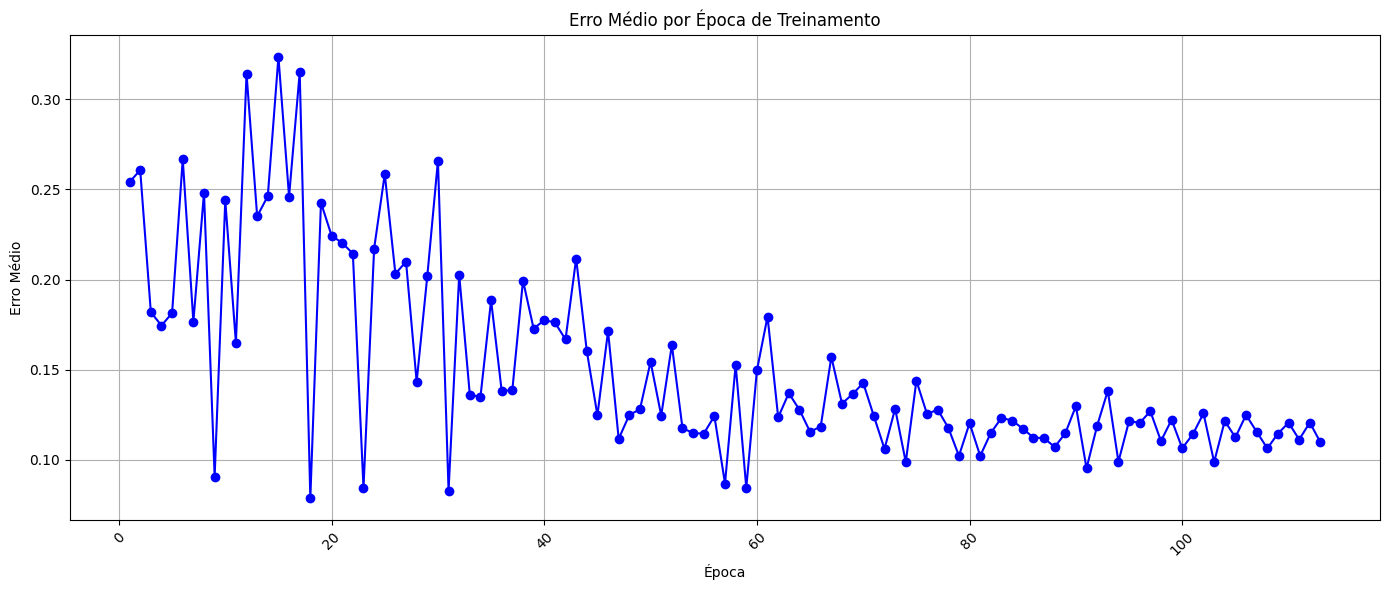

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(epocas_registradas, erros_por_epoca, marker='o', linestyle='-', color='blue')
plt.title('Erro Médio por Época de Treinamento')
plt.xlabel('Época')
plt.ylabel('Erro Médio')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Matriz de Confusão e Relatório de Classificação

Agora vamos gerar a matriz de confusão e um relatório de classificação para avaliar o desempenho do modelo de forma mais detalhada.

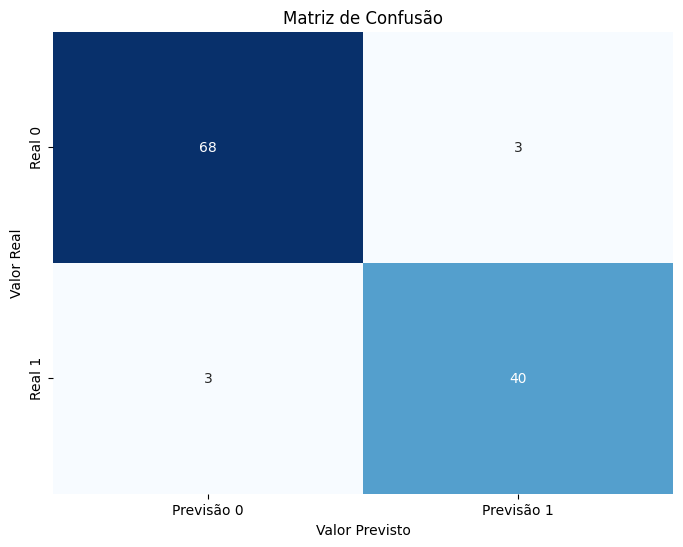


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Re-run predictions for the test set using the final weights
predictions = []
actual_outcomes = []

for i in range(len(y_test)):
    # Neuronio 1 (Camada Oculta)
    u_21_test = func_u(w_bias_1, bias_1, w_111, w_121, x_test[i][0], x_test[i][1])
    y_chapeu_21_test = sig(u_21_test)

    # Neuronio 2 (Camada Oculta)
    u_22_test = func_u(w_bias_2, bias_2, w_112, w_122, x_test[i][0], x_test[i][1])
    y_chapeu_22_test = sig(u_22_test)

    # Neuronio 3 (Camada de Saída)
    u_31_test = func_u(w_bias_3, bias_3, w_211, w_221, y_chapeu_21_test, y_chapeu_22_test)
    y_chapeu_31_test = sig(u_31_test)

    # Convertendo a saída para uma previsão binária (0 ou 1)
    prediction = 1 if y_chapeu_31_test >= 0.5 else 0
    predictions.append(prediction)
    actual_outcomes.append(y_test[i])


# Gerar a matriz de confusão
cm = confusion_matrix(actual_outcomes, predictions)

# Plotar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Previsão 0', 'Previsão 1'],
            yticklabels=['Real 0', 'Real 1'])
plt.xlabel('Valor Previsto')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusão')
plt.show()

# Gerar e imprimir o relatório de classificação
print('\nRelatório de Classificação:')
print(classification_report(actual_outcomes, predictions))

Legenda:

*   1 : Maligno
*   0: Benigno





### Curva ROC (Receiver Operating Characteristic) e AUC (Area Under the Curve)

A Curva ROC é uma ferramenta gráfica para avaliar o desempenho de um classificador binário. Ela mostra a taxa de verdadeiros positivos (TPR) versus a taxa de falsos positivos (FPR) em vários limiares de discriminação. A AUC representa a capacidade do modelo de distinguir entre as classes.

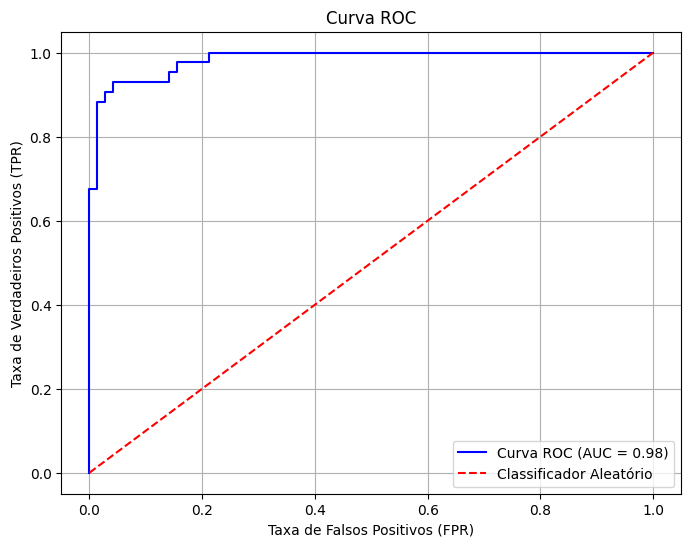

AUC (Area Under the Curve): 0.98


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate probabilities for the test set
y_ch_31_test_probabilities = []

for i in range(len(y_test)):
    # Neuronio 1 (Camada Oculta)
    u_21_test = func_u(w_bias_1, bias_1, w_111, w_121, x_test[i][0], x_test[i][1])
    y_chapeu_21_test = sig(u_21_test)

    # Neuronio 2 (Camada Oculta)
    u_22_test = func_u(w_bias_2, bias_2, w_112, w_122, x_test[i][0], x_test[i][1])
    y_chapeu_22_test = sig(u_22_test)

    # Neuronio 3 (Camada de Saída)
    u_31_test = func_u(w_bias_3, bias_3, w_211, w_221, y_chapeu_21_test, y_chapeu_22_test)
    y_chapeu_31_test = sig(u_31_test)

    y_ch_31_test_probabilities.append(y_chapeu_31_test)

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(actual_outcomes, y_ch_31_test_probabilities)
auc_score = roc_auc_score(actual_outcomes, y_ch_31_test_probabilities)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Classificador Aleatório')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()

print(f'AUC (Area Under the Curve): {auc_score:.2f}')

### Dados Fictícios de Pacientes para Teste

In [ ]:
# Criando um DataFrame com 3 pacientes fictícios
fictitious_patients_data = {
    'id': [900001, 900002, 900003],
    'diagnosis': [0, 1, 0], # 0: Benigno, 1: Maligno
    'perimeter_mean': [70.0, 105.0, 80.0],
    'texture_worst': [15.0, 28.0, 20.0]
}

fictitious_patients_df = pd.DataFrame(fictitious_patients_data)
display(fictitious_patients_df)

,id,diagnosis,perimeter_mean,texture_worst
0,900001,0,70.0,15.0
1,900002,1,105.0,28.0
2,900003,0,80.0,20.0


### Dados Fictícios de Pacientes com Correlação Média

In [ ]:
# Criando um DataFrame com mais 3 pacientes fictícios com correlação média
fictitious_patients_medium_corr_data = {
    'id': [900004, 900005, 900006],
    'diagnosis': [1, 0, 1], # 0: Benigno, 1: Maligno
    'perimeter_mean': [110.0, 75.0, 100.0], # Valores um pouco mais correlacionados com o diagnóstico
    'texture_worst': [25.0, 18.0, 22.0] # Valores um pouco mais correlacionados com o diagnóstico
}

fictitious_patients_medium_corr_df = pd.DataFrame(fictitious_patients_medium_corr_data)
display(fictitious_patients_medium_corr_df)

,id,diagnosis,perimeter_mean,texture_worst
0,900004,1,110.0,25.0
1,900005,0,75.0,18.0
2,900006,1,100.0,22.0


### Dados Fictícios de Pacientes com Correlação Alta

In [ ]:
# Criando um DataFrame com mais 3 pacientes fictícios com alta correlação
fictitious_patients_high_corr_data = {
    'id': [900007, 900008, 900009,],
    'diagnosis': [1, 0, 1], # 0: Benigno, 1: Maligno
    'perimeter_mean': [120.0, 65.0, 130.0], # Valores fortemente correlacionados com o diagnóstico
    'texture_worst': [30.0, 12.0, 35.0] # Valores fortemente correlacionados com o diagnóstico
}

fictitious_patients_high_corr_df = pd.DataFrame(fictitious_patients_high_corr_data)
display(fictitious_patients_high_corr_df)

,id,diagnosis,perimeter_mean,texture_worst
0,900007,1,120.0,30.0
1,900008,0,65.0,12.0
2,900009,1,130.0,35.0


### Sistema de Teste para Novos Pacientes

Agora, vamos implementar um sistema para prever o diagnóstico de câncer de mama para novos pacientes, utilizando os pesos da rede neural treinada. É crucial que os dados dos novos pacientes sejam normalizados da mesma forma que os dados de treinamento.

In [ ]:
# Calcular a média e o desvio padrão dos dados de treinamento originais para normalização
mean_orig_perimeter = df['perimeter_mean'].mean()
std_orig_perimeter = df['perimeter_mean'].std()
mean_orig_texture = df['texture_worst'].mean()
std_orig_texture = df['texture_worst'].std()

def predict_single_patient(p_mean, t_worst, w_111, w_121, w_bias_1, bias_1, w_112, w_122, w_bias_2, bias_2, w_211, w_221, w_bias_3, bias_3):
  # Normalizar os dados do novo paciente usando a média e o desvio padrão dos dados de treinamento
  z_p_mean = (p_mean - mean_orig_perimeter) / std_orig_perimeter
  z_t_worst = (t_worst - mean_orig_texture) / std_orig_texture

  # Neurônio 1 (Camada Oculta)
  u_21 = func_u(w_bias_1, bias_1, w_111, w_121, z_p_mean, z_t_worst)
  y_chapeu_21 = sig(u_21)

  # Neurônio 2 (Camada Oculta)
  u_22 = func_u(w_bias_2, bias_2, w_112, w_122, z_p_mean, z_t_worst)
  y_chapeu_22 = sig(u_22)

  # Neurônio 3 (Camada de Saída)
  u_31 = func_u(w_bias_3, bias_3, w_211, w_221, y_chapeu_21, y_chapeu_22)
  y_chapeu_31 = sig(u_31)

  # Retorna a probabilidade e a previsão binária
  return y_chapeu_31, 1 if y_chapeu_31 >= 0.5 else 0


# Lista de DataFrames de pacientes fictícios para teste
fictitious_dfs = {
    "Pacientes Fictícios (Correlação Baixa)": fictitious_patients_df,
    "Pacientes Fictícios (Correlação Média)": fictitious_patients_medium_corr_df,
    "Pacientes Fictícios (Correlação Alta)": fictitious_patients_high_corr_df
}

for df_name, current_df in fictitious_dfs.items():
    print(f"\n--- Testando: {df_name} ---")
    results = []
    for index, row in current_df.iterrows():
        patient_id = row['id']
        perimeter_mean = row['perimeter_mean']
        texture_worst = row['texture_worst']
        actual_diagnosis = row['diagnosis'] # Assumindo que 'diagnosis' é a verdade para os fictícios

        probability, prediction = predict_single_patient(
            perimeter_mean, texture_worst,
            w_111, w_121, w_bias_1, bias_1,
            w_112, w_122, w_bias_2, bias_2,
            w_211, w_221, w_bias_3, bias_3
        )
        results.append({
            'ID do Paciente': patient_id,
            'Perímetro Médio': perimeter_mean,
            'Textura Pior': texture_worst,
            'Diagnóstico Real': actual_diagnosis,
            'Probabilidade Prevista': f'{probability:.4f}',
            'Diagnóstico Previsto': prediction
        })
    display(pd.DataFrame(results))


--- Testando: Pacientes Fictícios (Correlação Baixa) ---


,ID do Paciente,Perímetro Médio,Textura Pior,Diagnóstico Real,Probabilidade Prevista,Diagnóstico Previsto
0,900001.0,70.0,15.0,0.0,0.4466,0
1,900002.0,105.0,28.0,1.0,0.5148,1
2,900003.0,80.0,20.0,0.0,0.4669,0



--- Testando: Pacientes Fictícios (Correlação Média) ---


,ID do Paciente,Perímetro Médio,Textura Pior,Diagnóstico Real,Probabilidade Prevista,Diagnóstico Previsto
0,900004.0,110.0,25.0,1.0,0.5165,1
1,900005.0,75.0,18.0,0.0,0.4569,0
2,900006.0,100.0,22.0,1.0,0.4992,0



--- Testando: Pacientes Fictícios (Correlação Alta) ---


,ID do Paciente,Perímetro Médio,Textura Pior,Diagnóstico Real,Probabilidade Prevista,Diagnóstico Previsto
0,900007.0,120.0,30.0,1.0,0.5317,1
1,900008.0,65.0,12.0,0.0,0.4379,0
2,900009.0,130.0,35.0,1.0,0.5414,1


###**Conclusão**

Conseguimos implementar uma boa acurácia, com isso a predição dos resultados ficou como o esperado.
As escolhas das variáveis influenciou positivamente nos resultados.
Para o banco de dados escolhido, a rede neural 2-2-1, foi o bastante, porém para bases mais complexas, talves seja necessário mais neurônios.
Tivemos problemas com a alta correlação entre os dados e a quantidade de dados era pequena.
O modelo poderia ser melhorado se houvesse mais dados para comparação.
Dito isso, o modelo neural foi satisfatório para a predição de malignidade do cancer de mama.